In [7]:
if(!require(readr)) install.packages("readr")
if(!require(readr)) install.packages("dplyr")
library(readr)
library(dplyr)

github="https://raw.githubusercontent.com/agronomy4future/raw_data_practice/main/wheat_yield_trend_over_60_years_by_faostat.csv"
FAOSTAT=data.frame(read_csv(url(github),show_col_types = FALSE))
FAOSTAT=subset(data.frame(read_csv(url(github),show_col_types=FALSE)), location!="S.Korea")
FAOSTAT=subset(FAOSTAT, year!="2021")
FAOSTAT$location=factor(FAOSTAT$location, levels=c("World","EU","US","Canada"))
FAOSTAT$trend=factor(FAOSTAT$trend,levels=c("1STWorld","2NDWorld","3RDWorld",
"1STEU","2NDEU","3RDEU","1STUS","2NDUS","3RDUS","1STCanada","2NDCanada",
"3RDCanada"))
FAOSTAT= FAOSTAT %>%
                 mutate(decade = case_when(
                 grepl("1ST", trend) ~ "1st_decade",
                 grepl("2ND", trend) ~ "2nd_decade",
                 grepl("3RD", trend) ~ "3rd_decade",
                 TRUE ~ NA_character_
  ))

df= FAOSTAT %>%
            group_by(location, year, trend, decade) %>%
            summarise(mean= mean(yield, na.rm= TRUE), .groups= "drop")

set.seed(100)
print(df[sample(nrow(df),5),])

# A tibble: 5 × 5
  location  year trend     decade      mean
  <fct>    <dbl> <fct>     <chr>      <dbl>
1 Canada    1982 2NDCanada 2nd_decade  2.13
2 EU        2002 3RDEU     3rd_decade  4.56
3 EU        2012 3RDEU     3rd_decade  4.80
4 Canada    1997 2NDCanada 2nd_decade  2.13
5 Canada    1986 2NDCanada 2nd_decade  2.21


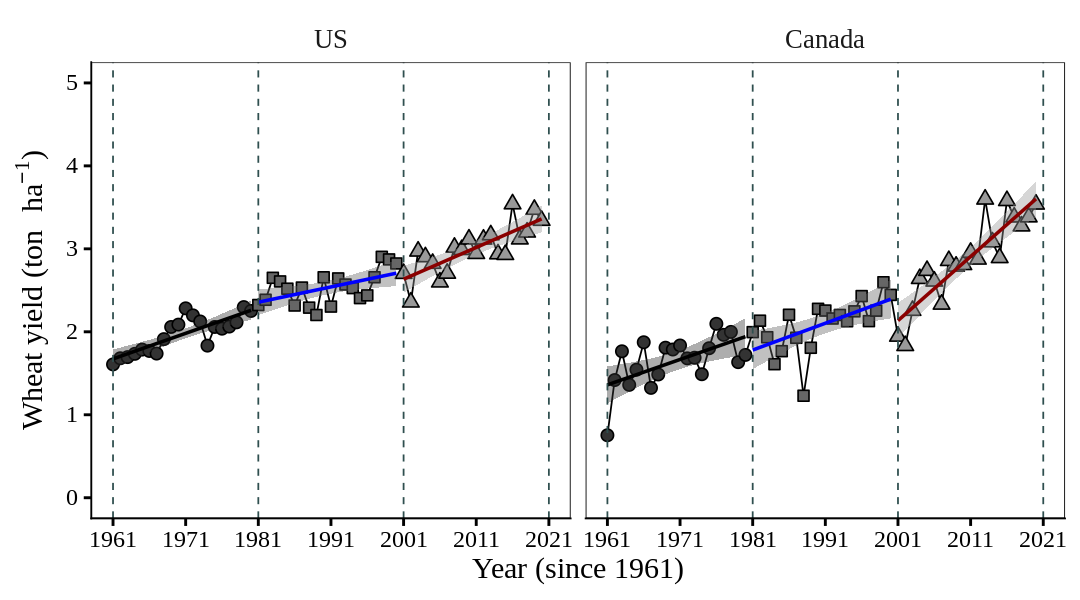

In [5]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

NAmerica= subset(df, location=="Canada" | location=="US")

Fig1= ggplot(data=NAmerica, aes(x=year, y=mean))+
  geom_line(linewidth=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend), size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,5,1),limits=c(0,5))+
  geom_vline(xintercept=1961,linetype="dashed",color="darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="darkslategray", linewidth=0.5)+
  facet_wrap(~location) +
  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=9, repr.plot.height=5)
print(Fig1)

ggsave("Fig1.png", plot= Fig1, width=9, height=5, dpi= 300)

In [ ]:
text1= data.frame(location="US", LabelText= "A)", year=1965, mean=5)
text2= data.frame(location="Canada", LabelText= "B)", year=1965, mean=5)

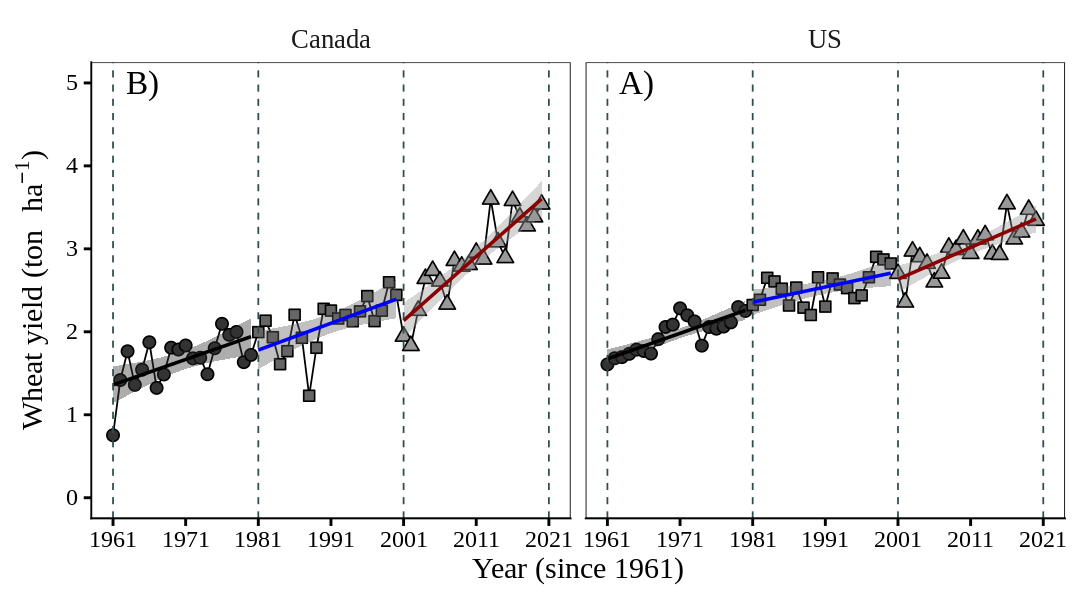

In [ ]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

Fig2= ggplot(data=subset(df, location=="Canada" | location=="US"), aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,5,1),limits=c(0,5))+

  geom_text(data=text1, aes(family="serif", x=year, y=mean, label=LabelText), size=7, color="black") +
  geom_text(data=text2, aes(family="serif", x=year, y=mean, label=LabelText), size=7, color="black") +

  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_wrap(~location) +
  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=9, repr.plot.height=5)
print(Fig2)

ggsave("Fig2.png", plot= Fig2, width=9, height=5, dpi= 300)

In [ ]:
text1_2= data.frame(location= factor(c("US", "Canada"), levels= c("US","Canada")),
         LabelText = c("A)", "B)"), year = 1965, mean = 5)

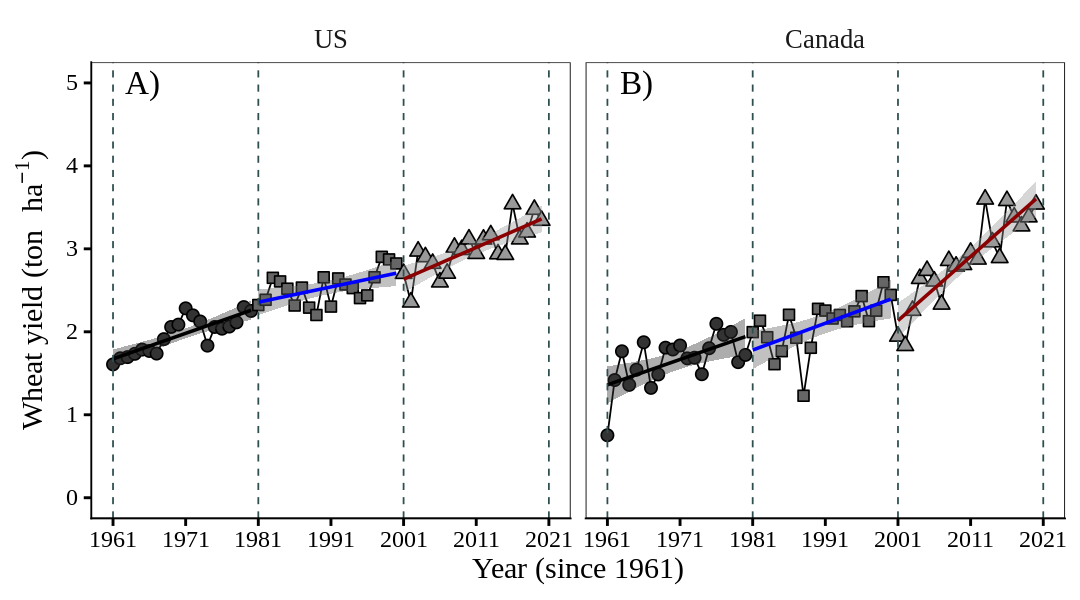

In [ ]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

Fig3= ggplot(data=subset(df, location=="Canada" | location=="US"), aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,5,1),limits=c(0,5))+

  geom_text(data = text1_2, aes(label = LabelText), family = "serif", size = 7) +

  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_wrap(~location) +
  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=9, repr.plot.height=5)
print(Fig3)

ggsave("Fig3.png", plot= Fig3, width=9, height=5, dpi= 300)

#facetext(): Easy Text Annotation for ggplot2 Faceted Plots

Before installing, please download Rtools (https://cran.r-project.org/bin/windows/Rtools)

In [ ]:
if(!require(remotes)) install.packages("remotes")
if (!requireNamespace("facetext", quietly = TRUE)) {
  remotes::install_github("agronomy4future/facetext", force= TRUE)
}
library(remotes)
library(facetext)

Basic usage of the facetext() function.

In [ ]:
facetext(
  data      = same data frame as in ggplot(i.e., data = df)
  facet_var = same variable as in facet_wrap(~ ***)
  x_var     = same variable as in aes(x= ***)
  x         = relative x position (0= left, 0.5= center, 1= right)
  yrange    = same y-axis range as in scale_y_continuous(limits= c(*, *))
  y         = relative y position (0= bottom, 1= top)
  label     = text labels displayed in each panel
  color     = text color per label
  size      = font size passed to geom_text()
  family    = font family passed to geom_text()
)

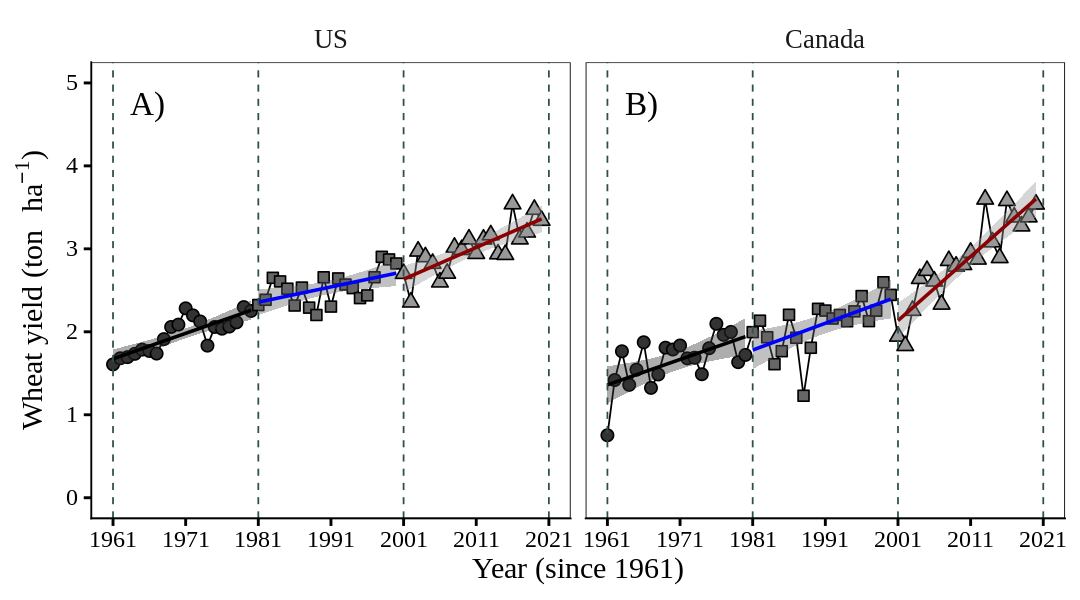

In [10]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

NAmerica= subset(df, location=="Canada" | location=="US")

Fig4= ggplot(data=NAmerica, aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,5,1),limits=c(0,5))+
  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_wrap(~location) +

  facetext(data= NAmerica,
           facet_var="location", x_var="year", x=c(0.08, 0.08),
           yrange=c(0, 5), y=c(0.95, 0.95), label=c("A)", "B)"),
           color=c("black", "black"), size=7, family="serif") +

  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=9, repr.plot.height=5)
print(Fig4)

ggsave("Fig4.png", plot= Fig4, width=9, height=5, dpi= 300)

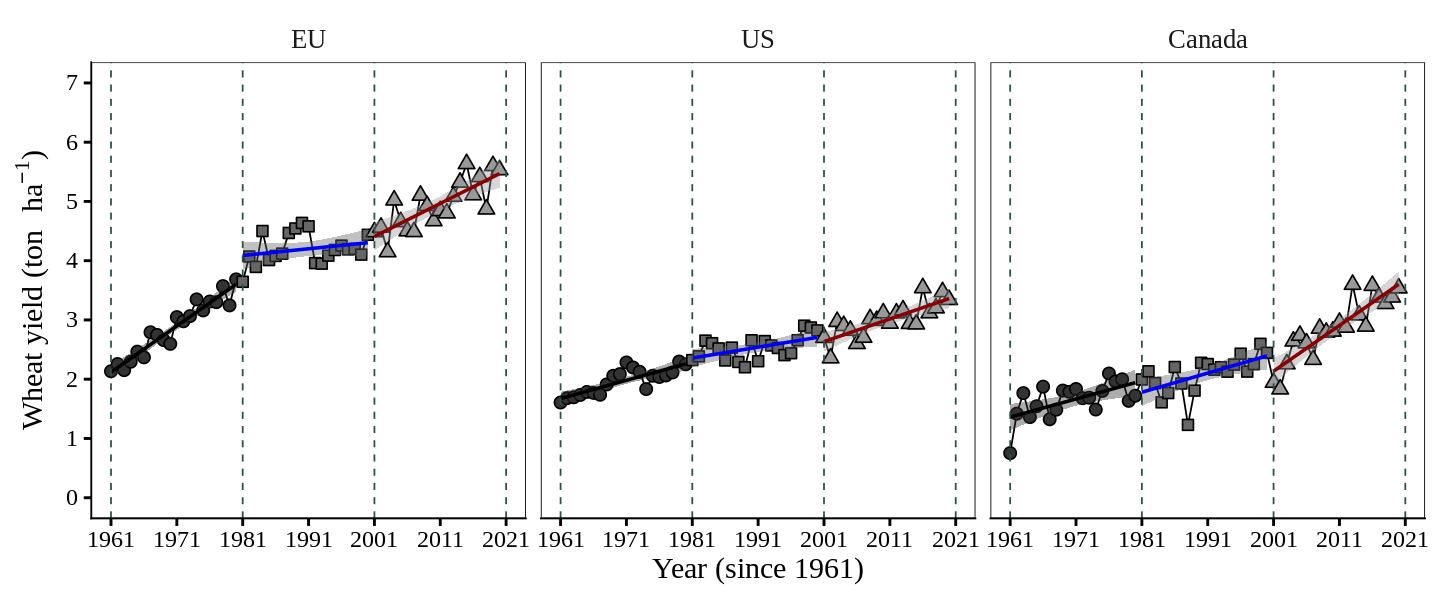

In [11]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

NAmericaE= subset(df, location=="Canada" | location=="US" | location=="EU")

Fig5= ggplot(data=NAmericaE, aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,7,1),limits=c(0,7))+
  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_wrap(~location) +
  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=12, repr.plot.height=5)
print(Fig5)

ggsave("Fig5.png", plot= Fig5, width=12, height=5, dpi= 300)

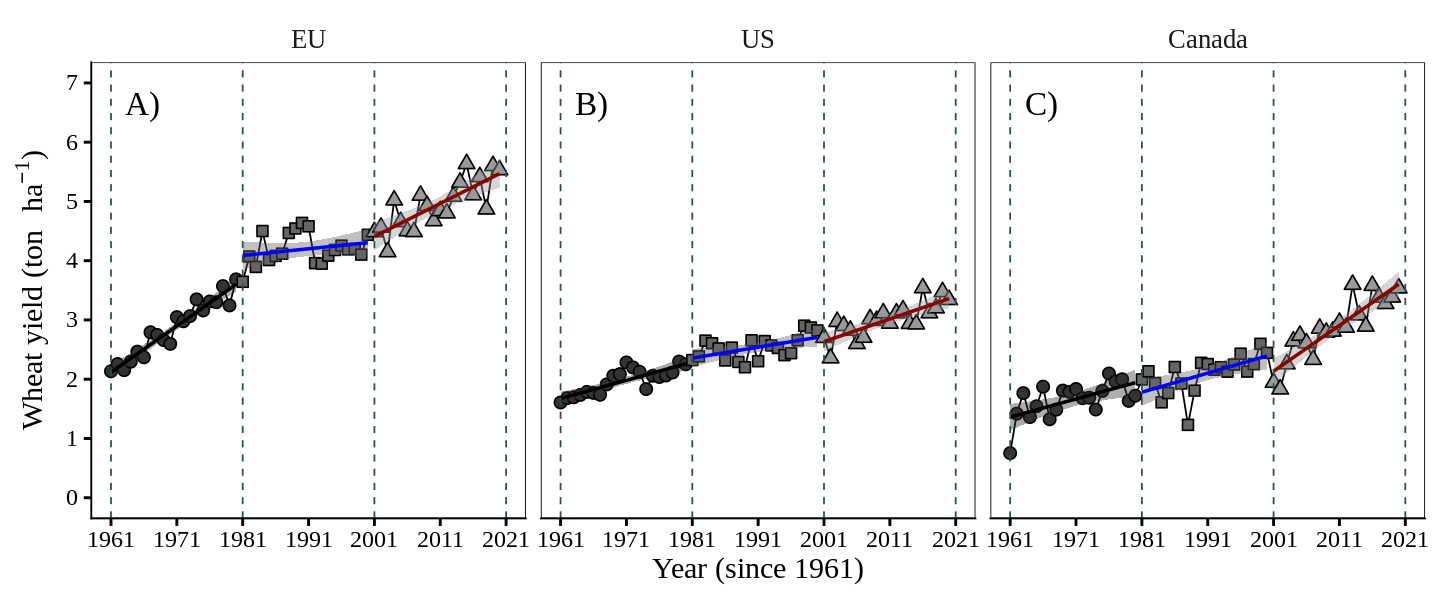

In [ ]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

NAmericaE= subset(df, location=="Canada" | location=="US" | location=="EU")

Fig6= ggplot(data=NAmericaE, aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,7,1),limits=c(0,7))+
  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_wrap(~location) +

  facetext(data= NAmericaE,
           facet_var="location", x_var="year", x=c(0.08, 0.08, 0.08),
           yrange=c(0, 7), y=c(0.95, 0.95, 0.95), label=c("A)", "B)", "C)"),
           color=c("black", "black", "black"), size=7, family="serif") +

  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=12, repr.plot.height=5)
print(Fig6)

ggsave("Fig6.png", plot= Fig6, width=12, height=5, dpi= 300)

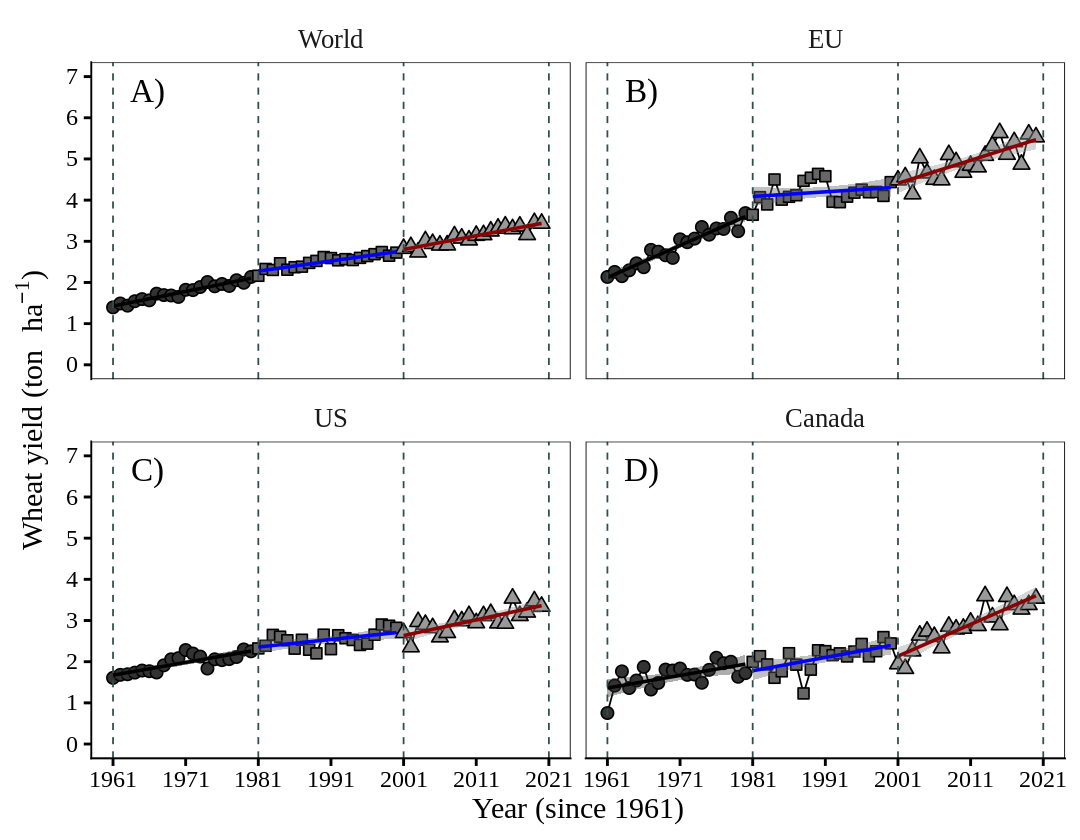

In [12]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

Fig7= ggplot(data=df, aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,7,1),limits=c(0,7))+
  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_wrap(~location, nrow=2) +

  facetext(data= df,
           facet_var="location", x_var="year", x=c(0.08, 0.08, 0.08, 0.08),
           yrange=c(0, 7), y=c(0.95, 0.95, 0.95, 0.95), label=c("A)", "B)", "C)", "D)"),
           color=c("black", "black", "black", "black"), size=7, family="serif") +

  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=9, repr.plot.height=7)
print(Fig7)

ggsave("Fig7.png", plot= Fig7, width=9, height=7, dpi= 300)

# facetext2(): Easy Text Annotation for ggplot2 Two-variable Faceted Plots

In [15]:
if(!require(remotes)) install.packages("remotes")
if (!requireNamespace("facetext2", quietly = TRUE)) {
  remotes::install_github("agronomy4future/facetext2", force= TRUE)
}
library(remotes)
library(facetext2)

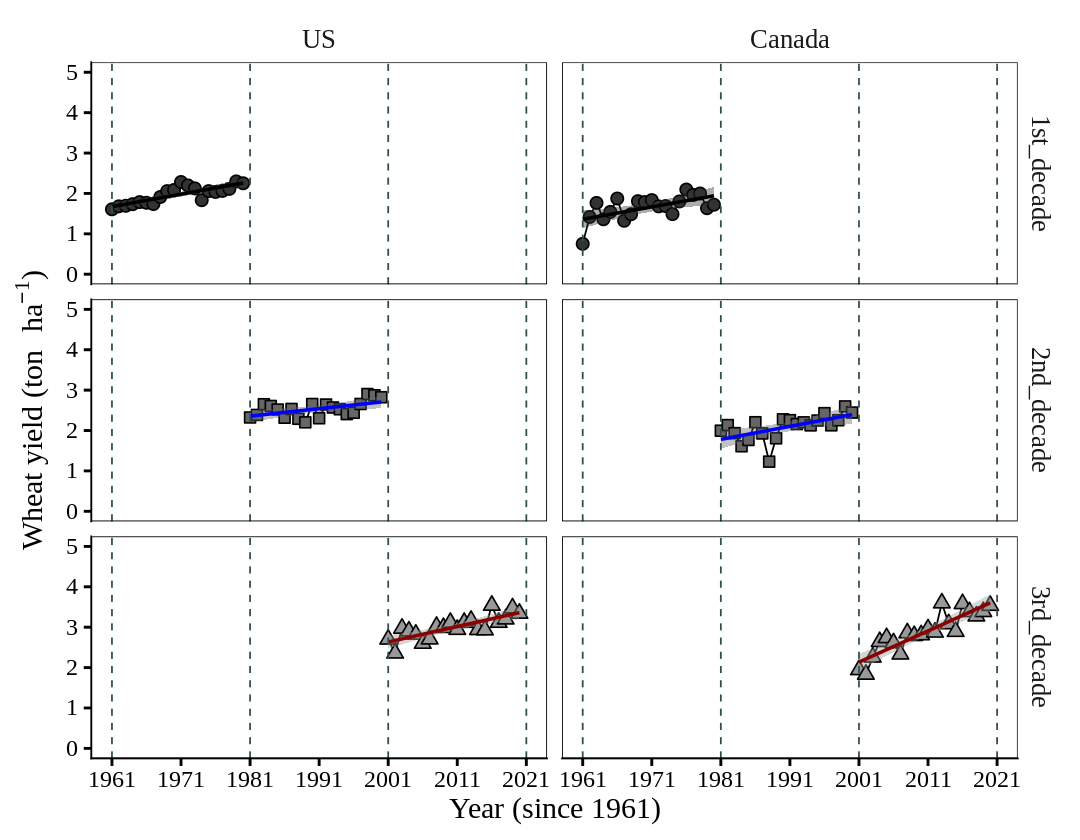

In [16]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

NAmerica= subset(df, location=="Canada" | location=="US")

Fig8= ggplot(data=NAmerica, aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,5,1),limits=c(0,5))+
  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_grid(decade ~location) +
  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=9, repr.plot.height=7)
print(Fig8)

ggsave("Fig8.png", plot= Fig8, width=9, height=7, dpi= 300)

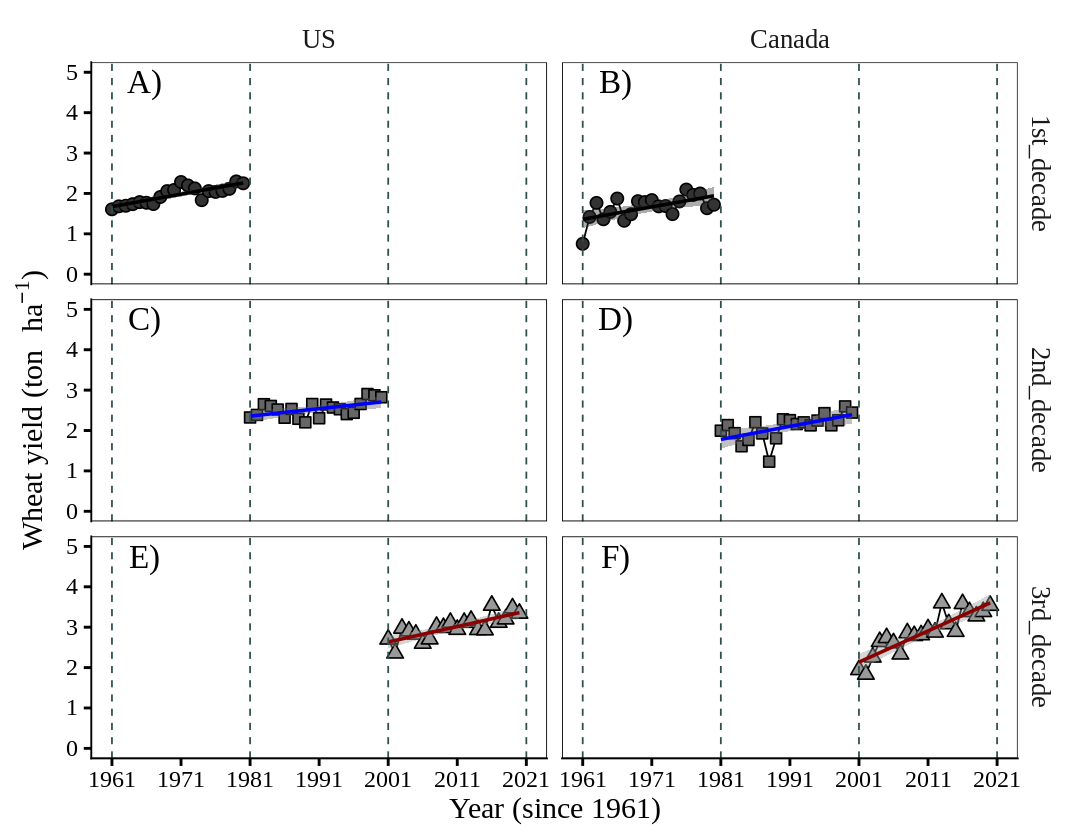

In [20]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

NAmerica= subset(df, location=="Canada" | location=="US")

Fig9= ggplot(data=NAmerica, aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,5,1),limits=c(0,5))+
  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_grid(decade ~location) +

  facetext2(data= NAmerica, facet_var= "location", facet_var2= "decade",
                            #Note: facet_var=column direction, facet_var2= row direction
                  x_var= "year", x = rep(0.08, 6), y= rep(0.95, 6),
                  yrange= c(0, 5), label= c("A)","C)","E)","B)","D)","F)"),
                  color= rep("black", 6), size= 7, family= "serif") +

  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=9, repr.plot.height=7)
print(Fig9)

ggsave("Fig9.png", plot= Fig9, width=9, height=7, dpi= 300)

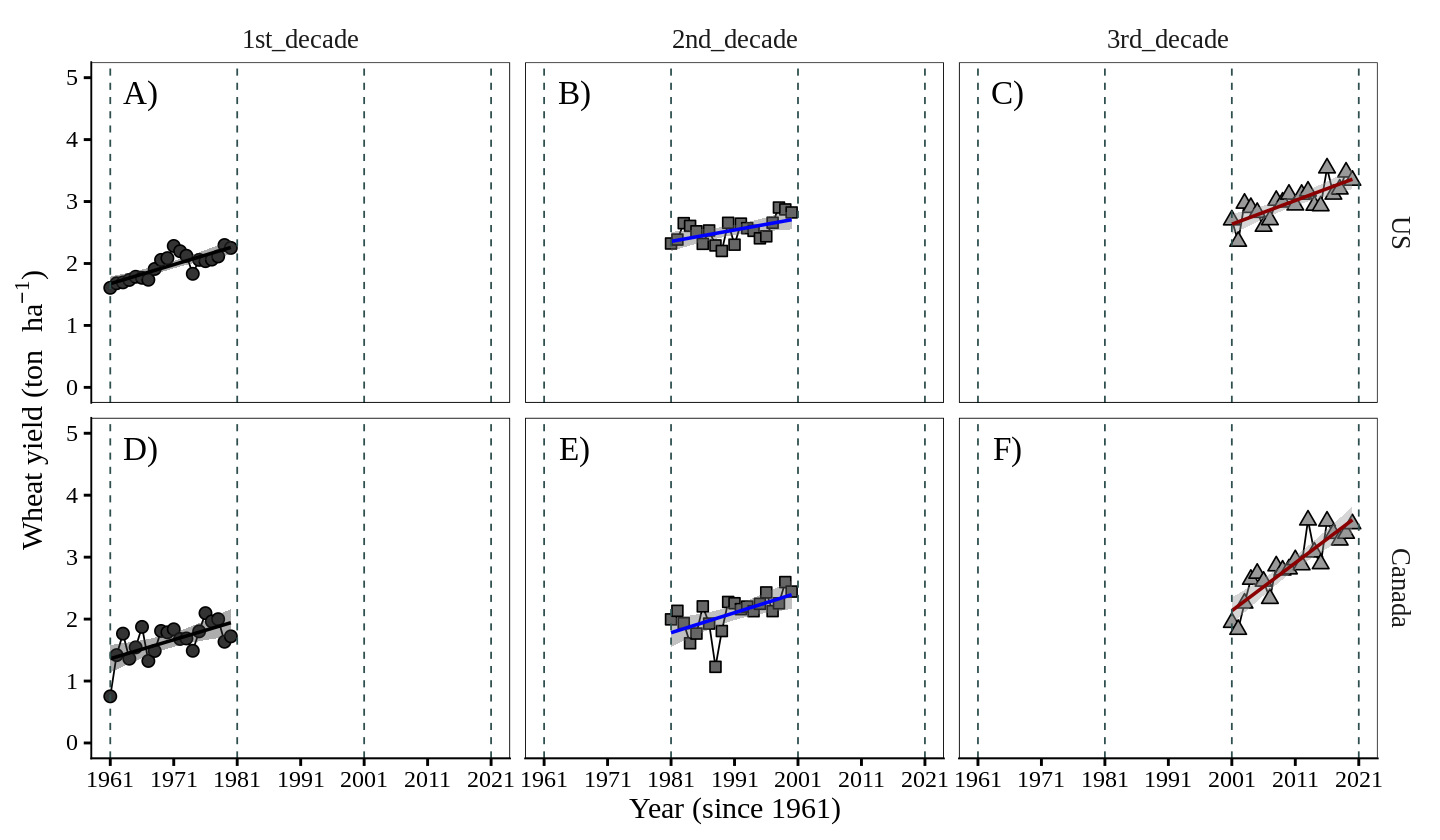

In [18]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

NAmerica= subset(df, location=="Canada" | location=="US")

Fig10= ggplot(data=NAmerica, aes(x=year, y=mean))+
  geom_line(size=0.5,linetype="solid")+
  geom_point(aes(fill=trend, shape=trend),size=3, stroke=0.7)+
  geom_smooth(aes(fill=trend, color=trend), method=lm, level=0.95,
              se=TRUE, linetype=1, size=1, formula=y~x)+
  scale_shape_manual(values=rep(c(21,22,24),4))+
  scale_fill_manual(values=rep(c("grey20","grey40","grey60"),4))+
  scale_color_manual(values=rep(c("Black","Blue","Dark red"),4))+
  scale_x_continuous(breaks=seq(1961,2021,10),limits=c(1961,2021))+
  scale_y_continuous(breaks=seq(0,5,1),limits=c(0,5))+
  geom_vline(xintercept=1961,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=1981,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2001,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  geom_vline(xintercept=2021,linetype="dashed",color="Darkslategray", linewidth=0.5)+
  facet_grid(location ~ decade) +

  facetext2(data= NAmerica, facet_var= "decade", facet_var2= "location",
                            #Note: facet_var=column direction, facet_var2= row direction
                  x_var= "year", x = rep(0.08, 6), y= rep(0.95, 6),
                  yrange= c(0, 5), label= c("A)","D)","B)","E)","C)","F)"),
                  color= rep("black", 6), size= 7, family= "serif") +

  ylab(bquote("Wheat yield (ton" ~ ha^-1*')'))+
  labs(x="Year (since 1961)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        strip.background=element_rect(color="white",
                         linewidth=0.5, linetype="solid"),
        strip.text = element_text(size = 16),
        axis.line=element_line(linewidth=0.5, colour="black"))

options(repr.plot.width=12, repr.plot.height=7)
print(Fig10)

ggsave("Fig10.png", plot= Fig10, width=12, height=7, dpi= 300)